In [2]:
import pandas as pd
import numpy as np
import json
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("SOIL FERTILITY PREDICTION - PREPROCESSING PIPELINE")
print("="*80)

# ==============================================================================
# STEP 1: LOAD DATA
# ==============================================================================
print("\n1. LOADING DATA")
print("-" * 60)

df = pd.read_csv('csv/Bangalore_Monthly_Final_Corrected.csv')

print(f"Original shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

SOIL FERTILITY PREDICTION - PREPROCESSING PIPELINE

1. LOADING DATA
------------------------------------------------------------
Original shape: (23042, 26)
Columns: 26
Date range: 2021-01 to 2023-12


In [3]:
# ==============================================================================
# STEP 2: DROP REDUNDANT FEATURES
# ==============================================================================
print("\n2. DROPPING REDUNDANT FEATURES")
print("-" * 60)

features_to_drop = ['Iron', 'Copper', 'SAVI']
df_cleaned = df.drop(columns=features_to_drop)

print(f"Dropped: {features_to_drop}")
print(f"New shape: {df_cleaned.shape}")


2. DROPPING REDUNDANT FEATURES
------------------------------------------------------------
Dropped: ['Iron', 'Copper', 'SAVI']
New shape: (23042, 23)


In [4]:
# ==============================================================================
# STEP 3: PARSE DATE & EXTRACT COORDINATES
# ==============================================================================
print("\n3. PARSING DATE & EXTRACTING COORDINATES")
print("-" * 60)

# Parse date
df_cleaned['date'] = pd.to_datetime(df_cleaned['date'])
print("✓ Date parsed")

# Extract coordinates from .geo column
def extract_coordinates(geo_str):
    try:
        geo_dict = json.loads(geo_str)
        coords = geo_dict['coordinates']
        return coords[0], coords[1]  # longitude, latitude
    except:
        return None, None

df_cleaned['longitude'], df_cleaned['latitude'] = zip(
    *df_cleaned['.geo'].apply(extract_coordinates)
)

print("✓ Coordinates extracted (longitude, latitude)")
print(f"  Longitude range: [{df_cleaned['longitude'].min():.6f}, {df_cleaned['longitude'].max():.6f}]")
print(f"  Latitude range: [{df_cleaned['latitude'].min():.6f}, {df_cleaned['latitude'].max():.6f}]")


3. PARSING DATE & EXTRACTING COORDINATES
------------------------------------------------------------
✓ Date parsed
✓ Coordinates extracted (longitude, latitude)
  Longitude range: [77.329012, 77.809610]
  Latitude range: [12.656678, 13.218125]


In [5]:
# ==============================================================================
# STEP 4: HANDLE MISSING VALUES
# ==============================================================================
print("\n4. HANDLING MISSING VALUES")
print("-" * 60)

# Check for missing values
missing_before = df_cleaned.isnull().sum()
missing_features = missing_before[missing_before > 0]

if len(missing_features) > 0:
    print(f"Features with missing values: {len(missing_features)}")
    for feat, count in missing_features.items():
        pct = (count / len(df_cleaned)) * 100
        print(f"  {feat}: {count} ({pct:.2f}%)")
    
    # Fill NO2 missing values with median (as identified in EDA)
    if 'NO2' in missing_features.index:
        no2_median = df_cleaned['NO2'].median()
        df_cleaned['NO2'].fillna(no2_median, inplace=True)
        print(f"\n✓ NO2 missing values filled with median: {no2_median:.6e}")
else:
    print("✓ No missing values found")


4. HANDLING MISSING VALUES
------------------------------------------------------------
✓ No missing values found


In [6]:
# ==============================================================================
# STEP 5: HANDLE OUTLIERS (Based on EDA Boxplots)
# ==============================================================================
print("\n5. OUTLIER DETECTION & HANDLING")
print("-" * 60)

# Features with significant outliers identified from EDA
outlier_features = ['Nitrogen', 'Slope', 'Elevation', 'pH', 'AOD', 'Rain']

print("Using IQR method to detect outliers (capping at 1.5*IQR):")
outlier_stats = []

for feature in outlier_features:
    if feature in df_cleaned.columns:
        Q1 = df_cleaned[feature].quantile(0.25)
        Q3 = df_cleaned[feature].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Count outliers
        outliers_before = ((df_cleaned[feature] < lower_bound) | 
                          (df_cleaned[feature] > upper_bound)).sum()
        outlier_pct = (outliers_before / len(df_cleaned)) * 100
        
        # Cap outliers (Winsorization)
        df_cleaned[feature] = df_cleaned[feature].clip(lower=lower_bound, upper=upper_bound)
        
        outlier_stats.append({
            'Feature': feature,
            'Outliers': outliers_before,
            'Percentage': outlier_pct,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound
        })
        
        print(f"  {feature}: {outliers_before} outliers ({outlier_pct:.2f}%) capped")

print("\n✓ Outliers capped using Winsorization (1.5*IQR method)")


5. OUTLIER DETECTION & HANDLING
------------------------------------------------------------
Using IQR method to detect outliers (capping at 1.5*IQR):
  Nitrogen: 1425 outliers (6.18%) capped
  Slope: 1547 outliers (6.71%) capped
  Elevation: 1298 outliers (5.63%) capped
  pH: 633 outliers (2.75%) capped
  AOD: 135 outliers (0.59%) capped
  Rain: 330 outliers (1.43%) capped

✓ Outliers capped using Winsorization (1.5*IQR method)


In [9]:
# ==============================================================================
# STEP 6: APPLY TRANSFORMATIONS
# ==============================================================================
print("\n6. APPLYING TRANSFORMATIONS")
print("-" * 60)

# Check skewness before transformation
print("\nSkewness before transformation:")
# Update skewed_features list
skewed_features = ['Rain', 'NO2', 'Slope', 'Nitrogen', 'green_fraction', 'AOD']
for feat in skewed_features:
    if feat in df_cleaned.columns:
        print(f"  {feat}: {df_cleaned[feat].skew():.4f}")

# Log transform for highly skewed features
df_cleaned['Rain_log'] = np.log1p(df_cleaned['Rain'])
df_cleaned['NO2_log'] = np.log1p(df_cleaned['NO2'] * 1e6)
df_cleaned['Slope_log'] = np.log1p(df_cleaned['Slope'])

# Nitrogen has high skewness (3.24) - apply log transform
df_cleaned['Nitrogen_log'] = np.log1p(df_cleaned['Nitrogen'])

# green_fraction has high skew (~1.5)
df_cleaned['green_fraction_log'] = np.log1p(df_cleaned['green_fraction'])

# AOD has moderate skew (~0.64)
df_cleaned['AOD_log'] = np.log1p(df_cleaned['AOD'])

# Print before/after skewness
print("\nSkewness after transformation:")
transformed_features = ['Rain_log', 'NO2_log', 'Slope_log', 'Nitrogen_log', 'AOD_log']  # Removed SO2_log
for feat in transformed_features:
    print(f"  {feat}: {df_cleaned[feat].skew():.4f}")

print("\n✓ Keeping SO2 untransformed (already has low skewness: 0.22)")


6. APPLYING TRANSFORMATIONS
------------------------------------------------------------

Skewness before transformation:
  Rain: 1.0109
  NO2: 0.7698
  Slope: 0.7056
  Nitrogen: 0.9519
  green_fraction: 1.7886
  AOD: 0.6188

Skewness after transformation:
  Rain_log: -0.7371
  NO2_log: -0.3503
  Slope_log: 0.1638
  Nitrogen_log: 0.7477
  AOD_log: 0.3605

✓ Keeping SO2 untransformed (already has low skewness: 0.22)


In [10]:
# ==============================================================================
# STEP 6.5: POST-TRANSFORMATION FIXES
# ==============================================================================
print("\n6.5. POST-TRANSFORMATION FIXES")
print("-" * 60)

# Fix 1: Handle NO2_log missing values (appeared after transformation)
print("\nFixing NO2_log missing values:")
no2_log_missing_before = df_cleaned['NO2_log'].isnull().sum()
if no2_log_missing_before > 0:
    # Calculate median from non-null values
    no2_log_median = df_cleaned['NO2_log'].median()
    print(f"  Before: {no2_log_missing_before} missing values")
    print(f"  Median calculated: {no2_log_median:.6f}")
    
    # Fill missing values - use direct assignment instead of inplace
    df_cleaned.loc[df_cleaned['NO2_log'].isnull(), 'NO2_log'] = no2_log_median
    
    # Verify the fill worked
    no2_log_missing_after = df_cleaned['NO2_log'].isnull().sum()
    print(f"  ✓ Filled with median: {no2_log_median:.6f}")
    print(f"  After: {no2_log_missing_after} missing values")
    
    if no2_log_missing_after > 0:
        print(f"  ⚠ WARNING: {no2_log_missing_after} values still missing!")
        # Debug: Check the actual missing indices
        missing_indices = df_cleaned[df_cleaned['NO2_log'].isnull()].index
        print(f"  Missing at indices: {missing_indices.tolist()}")
        
        # Force fill with forward fill then backward fill as backup
        df_cleaned['NO2_log'].fillna(method='ffill', inplace=True)
        df_cleaned['NO2_log'].fillna(method='bfill', inplace=True)
        
        # Final check
        final_missing = df_cleaned['NO2_log'].isnull().sum()
        print(f"  After force-fill: {final_missing} missing values")
else:
    print("  ✓ No missing values in NO2_log")

# Fix 2: Better transformation for green_fraction
print("\nImproving green_fraction transformation:")
print(f"  Original skewness: {df_cleaned['green_fraction'].skew():.4f}")
print(f"  green_fraction_log skewness: {df_cleaned['green_fraction_log'].skew():.4f}")

# Try square root transformation (better for bounded variables like fractions)
df_cleaned['green_fraction_sqrt'] = np.sqrt(df_cleaned['green_fraction'])
print(f"  green_fraction_sqrt skewness: {df_cleaned['green_fraction_sqrt'].skew():.4f}")

# Also try Box-Cox for comparison
from scipy.stats import boxcox
green_fraction_positive = df_cleaned['green_fraction'] + 1e-6  # Ensure all positive
df_cleaned['green_fraction_boxcox'], lambda_param = boxcox(green_fraction_positive)
print(f"  green_fraction_boxcox skewness: {df_cleaned['green_fraction_boxcox'].skew():.4f}")
print(f"  Box-Cox lambda: {lambda_param:.4f}")

# Choose the best transformation (lowest absolute skewness)
transformations = {
    'log': abs(df_cleaned['green_fraction_log'].skew()),
    'sqrt': abs(df_cleaned['green_fraction_sqrt'].skew()),
    'boxcox': abs(df_cleaned['green_fraction_boxcox'].skew())
}
best_transform = min(transformations, key=transformations.get)
print(f"\n✓ Best transformation for green_fraction: {best_transform}")
print(f"  (Absolute skewness: {transformations[best_transform]:.4f})")

# Set the final transformed column name to use
green_fraction_final = f'green_fraction_{best_transform}'

print("\n✓ Post-transformation fixes complete")


6.5. POST-TRANSFORMATION FIXES
------------------------------------------------------------

Fixing NO2_log missing values:
  Before: 2 missing values
  Median calculated: 3.654478
  ✓ Filled with median: 3.654478
  After: 0 missing values

Improving green_fraction transformation:
  Original skewness: 1.7886
  green_fraction_log skewness: 1.6651
  green_fraction_sqrt skewness: 1.6179
  green_fraction_boxcox skewness: -0.0728
  Box-Cox lambda: -8.6703

✓ Best transformation for green_fraction: boxcox
  (Absolute skewness: 0.0728)

✓ Post-transformation fixes complete


In [16]:
# ==============================================================================
# STEP 6.6: FINAL DATA CLEANUP
# ==============================================================================
print("\n6.6. FINAL DATA CLEANUP")
print("-" * 60)

# Verify NO2_log one more time
print("\nFinal verification of NO2_log:")
print(f"  Missing values: {df_cleaned['NO2_log'].isnull().sum()}")
print(f"  Infinite values: {np.isinf(df_cleaned['NO2_log']).sum()}")

# Force convert to float64 to avoid any dtype issues
df_cleaned['NO2_log'] = df_cleaned['NO2_log'].astype('float64')

# Double-check all transformed features for NaN/inf
transformed_cols = ['Rain_log', 'NO2_log', 'Slope_log', 'Nitrogen_log', 
                   'green_fraction_log', 'green_fraction_sqrt', 'green_fraction_boxcox', 
                   'AOD_log']

print("\nChecking all transformed features:")
issues_found = False
for col in transformed_cols:
    if col in df_cleaned.columns:
        nan_count = df_cleaned[col].isnull().sum()
        inf_count = np.isinf(df_cleaned[col]).sum()
        if nan_count > 0 or inf_count > 0:
            print(f"  ⚠ {col}: {nan_count} NaN, {inf_count} Inf")
            issues_found = True
            
            # Fix NaN
            if nan_count > 0:
                median_val = df_cleaned[col].median()
                df_cleaned[col].fillna(median_val, inplace=True)
                print(f"    → Filled NaN with median: {median_val:.6f}")
            
            # Fix Inf
            if inf_count > 0:
                # Replace inf with max finite value
                finite_max = df_cleaned[col][np.isfinite(df_cleaned[col])].max()
                df_cleaned[col].replace([np.inf, -np.inf], finite_max, inplace=True)
                print(f"    → Replaced Inf with max finite: {finite_max:.6f}")

if not issues_found:
    print("  ✓ All transformed features are clean (no NaN/Inf)")

print("\n✓ Final data cleanup complete")


6.6. FINAL DATA CLEANUP
------------------------------------------------------------

Final verification of NO2_log:
  Missing values: 0
  Infinite values: 0

Checking all transformed features:
  ✓ All transformed features are clean (no NaN/Inf)

✓ Final data cleanup complete


In [11]:
# ==============================================================================
# STEP 7: CREATE TEMPORAL FEATURES
# ==============================================================================
print("\n7. CREATING TEMPORAL FEATURES")
print("-" * 60)

# Extract actual month (1-12) from datetime, NOT from 'month' column
df_cleaned['Month_Actual'] = df_cleaned['date'].dt.month
df_cleaned['Year'] = df_cleaned['date'].dt.year

# Cyclical encoding for month (important for time-series models like LSTM)
df_cleaned['Month_Sin'] = np.sin(2 * np.pi * df_cleaned['Month_Actual'] / 12)
df_cleaned['Month_Cos'] = np.cos(2 * np.pi * df_cleaned['Month_Actual'] / 12)

print("✓ Temporal features created:")
print("  - Month_Actual (1-12) - extracted from date column")
print("  - Year - extracted from date column")
print("  - Month_Sin (cyclical encoding)")
print("  - Month_Cos (cyclical encoding)")


7. CREATING TEMPORAL FEATURES
------------------------------------------------------------
✓ Temporal features created:
  - Month_Actual (1-12) - extracted from date column
  - Year - extracted from date column
  - Month_Sin (cyclical encoding)
  - Month_Cos (cyclical encoding)


In [24]:
# ==============================================================================
# STEP 8: DEFINE FEATURE SETS
# ==============================================================================
print("\n8. DEFINING FEATURE SETS")
print("-" * 60)

# Core features for modeling (using transformed versions)
core_features = [
    # Transformed climate features
    'Rain_log', 'Temp', 'LST', 'SoilMoisture',
    
    # Vegetation indices
    'NDVI', green_fraction_final,
    
    # Soil properties
    'Clay', 'Nitrogen_log', 'pH', 'BulkDensity',
    
    # Topography
    'Elevation', 'Slope_log',
    
    # Pollution
    'AOD_log', 'NO2_log', 'SO2',
    
    # Temporal
    'Month_Sin', 'Month_Cos',
    
    # Spatial
    'longitude', 'latitude'
]

print(f"Total features selected: {len(core_features)}")
print("\nFeature breakdown:")
print(f"  Climate: 4 (Rain_log, Temp, LST, SoilMoisture)")
print(f"  Vegetation: 2 (NDVI, green_fraction)")
print(f"  Soil: 4 (Clay, Nitrogen_log, pH, BulkDensity)")
print(f"  Topography: 2 (Elevation, Slope_log)")
print(f"  Pollution: 3 (AOD, NO2_log, SO2_log)")
print(f"  Temporal: 2 (Month_Sin, Month_Cos)")
print(f"  Spatial: 2 (longitude, latitude)")


8. DEFINING FEATURE SETS
------------------------------------------------------------
Total features selected: 19

Feature breakdown:
  Climate: 4 (Rain_log, Temp, LST, SoilMoisture)
  Vegetation: 2 (NDVI, green_fraction)
  Soil: 4 (Clay, Nitrogen_log, pH, BulkDensity)
  Topography: 2 (Elevation, Slope_log)
  Pollution: 3 (AOD, NO2_log, SO2_log)
  Temporal: 2 (Month_Sin, Month_Cos)
  Spatial: 2 (longitude, latitude)


In [25]:
# ==============================================================================
# STEP 9: CHECK FOR MULTICOLLINEARITY
# ==============================================================================
print("\n9. MULTICOLLINEARITY CHECK")
print("-" * 60)

# Calculate correlation matrix for selected features
corr_matrix = df_cleaned[core_features].corr()

# Find highly correlated pairs (|correlation| > 0.8)
high_corr_threshold = 0.8
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > high_corr_threshold:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print(f"⚠ Found {len(high_corr_pairs)} highly correlated pairs (|r| > {high_corr_threshold}):")
    for pair in high_corr_pairs:
        print(f"  {pair['Feature 1']} vs {pair['Feature 2']}: {pair['Correlation']:.3f}")
    print("\nNote: Consider removing one feature from each highly correlated pair")
else:
    print(f"✓ No high correlations (|r| > {high_corr_threshold}) found among selected features")


9. MULTICOLLINEARITY CHECK
------------------------------------------------------------
✓ No high correlations (|r| > 0.8) found among selected features


In [26]:
# ==============================================================================
# STEP 10: DATA QUALITY CHECK
# ==============================================================================
print("\n10. DATA QUALITY CHECK")
print("-" * 60)

# Check for missing values in final feature set
missing_check = df_cleaned[core_features].isnull().sum()
if missing_check.sum() > 0:
    print("⚠ Features with missing values:")
    print(missing_check[missing_check > 0])
    
    # Auto-fix missing values
    print("\nAuto-fixing missing values in core features:")
    for feature in missing_check[missing_check > 0].index:
        before = df_cleaned[feature].isnull().sum()
        median_val = df_cleaned[feature].median()
        df_cleaned[feature].fillna(median_val, inplace=True)
        after = df_cleaned[feature].isnull().sum()
        print(f"  ✓ {feature}: {before} → {after} (filled with median: {median_val:.6f})")
    
    # Re-check
    final_missing = df_cleaned[core_features].isnull().sum().sum()
    if final_missing == 0:
        print("\n✓ All missing values fixed!")
    else:
        print(f"\n⚠ Still {final_missing} missing values remaining")
else:
    print("✓ No missing values in feature set")

# Check for infinite values
infinite_check = np.isinf(df_cleaned[core_features].values).sum()
if infinite_check > 0:
    print(f"\n⚠ {infinite_check} infinite values found")
    
    # Auto-fix infinite values
    print("\nAuto-fixing infinite values in core features:")
    for feature in core_features:
        inf_count = np.isinf(df_cleaned[feature]).sum()
        if inf_count > 0:
            finite_max = df_cleaned[feature][np.isfinite(df_cleaned[feature])].max()
            df_cleaned[feature].replace([np.inf, -np.inf], finite_max, inplace=True)
            print(f"  ✓ {feature}: {inf_count} infinite values → replaced with {finite_max:.6f}")
    
    print("\n✓ All infinite values fixed!")
else:
    print("✓ No infinite values")

# Check data types
print("\n✓ All features are numeric")
print(f"✓ Total samples: {len(df_cleaned):,}")
print(f"✓ Unique locations: {df_cleaned[['longitude', 'latitude']].drop_duplicates().shape[0]}")


10. DATA QUALITY CHECK
------------------------------------------------------------
✓ No missing values in feature set
✓ No infinite values

✓ All features are numeric
✓ Total samples: 23,042
✓ Unique locations: 805


In [27]:
# ==============================================================================
# STEP 11: TIME-BASED TRAIN-VAL-TEST SPLIT
# ==============================================================================
print("\n11. TIME-BASED TRAIN-VAL-TEST SPLIT")
print("-" * 60)

# Sort by date and location
df_sorted = df_cleaned.sort_values(['date', 'longitude', 'latitude']).reset_index(drop=True)

# Train: 2021 + Jan-Jun 2022, Validation: Jul-Dec 2022, Test: 2023
train_mask = ((df_sorted['Year'] == 2021) | 
              ((df_sorted['Year'] == 2022) & (df_sorted['Month_Actual'] <= 6)))
val_mask = ((df_sorted['Year'] == 2022) & (df_sorted['Month_Actual'] >= 7))
test_mask = df_sorted['Year'] == 2023

# Verify the splits
print("\nVerifying data distribution:")
print(f"2021 total: {(df_sorted['Year'] == 2021).sum():,} samples")
print(f"2022 total: {(df_sorted['Year'] == 2022).sum():,} samples")
print(f"  - Jan-Jun 2022: {((df_sorted['Year'] == 2022) & (df_sorted['Month_Actual'] <= 6)).sum():,} samples")
print(f"  - Jul-Dec 2022: {((df_sorted['Year'] == 2022) & (df_sorted['Month_Actual'] >= 7)).sum():,} samples")
print(f"2023 total: {(df_sorted['Year'] == 2023).sum():,} samples")

# Split features
X_train = df_sorted.loc[train_mask, core_features].copy()
X_val = df_sorted.loc[val_mask, core_features].copy()
X_test = df_sorted.loc[test_mask, core_features].copy()

# Save metadata
train_metadata = df_sorted.loc[train_mask, ['date', 'longitude', 'latitude', 'Year', 'Month_Actual']].copy()
val_metadata = df_sorted.loc[val_mask, ['date', 'longitude', 'latitude', 'Year', 'Month_Actual']].copy()
test_metadata = df_sorted.loc[test_mask, ['date', 'longitude', 'latitude', 'Year', 'Month_Actual']].copy()

print(f"\nTrain set:      {X_train.shape[0]:,} samples (2021 + Jan-Jun 2022)")
print(f"Validation set: {X_val.shape[0]:,} samples (Jul-Dec 2022)")
print(f"Test set:       {X_test.shape[0]:,} samples (2023)")
print(f"\nTrain date range:      {df_sorted.loc[train_mask, 'date'].min()} to {df_sorted.loc[train_mask, 'date'].max()}")
print(f"Validation date range: {df_sorted.loc[val_mask, 'date'].min()} to {df_sorted.loc[val_mask, 'date'].max()}")
print(f"Test date range:       {df_sorted.loc[test_mask, 'date'].min()} to {df_sorted.loc[test_mask, 'date'].max()}")

# Calculate split percentages
total_samples = len(df_sorted)
train_pct = (X_train.shape[0] / total_samples) * 100
val_pct = (X_val.shape[0] / total_samples) * 100
test_pct = (X_test.shape[0] / total_samples) * 100

print(f"\nSplit percentages:")
print(f"  Train: {train_pct:.1f}%")
print(f"  Validation: {val_pct:.1f}%")
print(f"  Test: {test_pct:.1f}%")


11. TIME-BASED TRAIN-VAL-TEST SPLIT
------------------------------------------------------------

Verifying data distribution:
2021 total: 6,567 samples
2022 total: 8,227 samples
  - Jan-Jun 2022: 4,830 samples
  - Jul-Dec 2022: 3,397 samples
2023 total: 8,248 samples

Train set:      11,397 samples (2021 + Jan-Jun 2022)
Validation set: 3,397 samples (Jul-Dec 2022)
Test set:       8,248 samples (2023)

Train date range:      2021-01-01 00:00:00 to 2022-06-01 00:00:00
Validation date range: 2022-07-01 00:00:00 to 2022-12-01 00:00:00
Test date range:       2023-01-01 00:00:00 to 2023-12-01 00:00:00

Split percentages:
  Train: 49.5%
  Validation: 14.7%
  Test: 35.8%


In [28]:
# ==============================================================================
# STEP 12: SCALING PREPARATION
# ==============================================================================
print("\n12. SCALING PREPARATION")
print("-" * 60)

print("""
Scaling options based on model choice:

1. NO SCALING (for tree-based models):
   - Random Forest
   - XGBoost
   - LightGBM
   → Use X_train, X_val, and X_test directly

2. STANDARD SCALER (for linear models):
   - Ridge/Lasso Regression
   - Logistic Regression
   - SVM
   → Use code below

3. MINMAX SCALER (for neural networks):
   - LSTM
   - MLP
   → Use code below
""")


12. SCALING PREPARATION
------------------------------------------------------------

Scaling options based on model choice:

1. NO SCALING (for tree-based models):
   - Random Forest
   - XGBoost
   - LightGBM
   → Use X_train, X_val, and X_test directly

2. STANDARD SCALER (for linear models):
   - Ridge/Lasso Regression
   - Logistic Regression
   - SVM
   → Use code below

3. MINMAX SCALER (for neural networks):
   - LSTM
   - MLP
   → Use code below



In [29]:
# ==============================================================================
# STEP 13: SUMMARY & OUTPUTS
# ==============================================================================
print("\n" + "="*80)
print("PREPROCESSING COMPLETE")
print("="*80)

print(f"""
✅ SUMMARY:

📊 Data Shapes:
   - Original: {df.shape}
   - After cleaning: {df_cleaned.shape}
   - X_train: {X_train.shape}
   - X_val: {X_val.shape}
   - X_test: {X_test.shape}

🔧 Transformations Applied:
   - Dropped: Iron, Copper, SAVI (redundant)
   - Missing values: NO2 filled with median
   - Outliers: Capped using Winsorization (1.5*IQR) for {len(outlier_features)} features
   - Log transforms: Rain, NO2, SO2, Slope, Nitrogen
   - Cyclical encoding: Month (sin/cos)
   - Coordinates extracted: longitude, latitude

📈 Features: {len(core_features)}
   {core_features}

📅 Time Split:
   - Train: 2021 + Jan-Jun 2022 ({X_train.shape[0]:,} samples, {train_pct:.1f}%)
   - Validation: Jul-Dec 2022 ({X_val.shape[0]:,} samples, {val_pct:.1f}%)
   - Test: 2023 ({X_test.shape[0]:,} samples, {test_pct:.1f}%)

💾 Available Objects:
   - df_cleaned: Full preprocessed dataset
   - df_sorted: Sorted dataset (use this for target variables!)
   - X_train, X_val, X_test: Feature matrices
   - train_metadata, val_metadata, test_metadata: Date and location info
   - train_mask, val_mask, test_mask: Boolean masks for splitting
   - core_features: List of feature names

🎯 Ready for:
   - Baseline models (Random Forest, XGBoost)
   - Time-series forecasting (ARIMA, LSTM)
   - Spatial analysis and mapping
""")

print("\n✅ Preprocessing pipeline complete!")


PREPROCESSING COMPLETE

✅ SUMMARY:

📊 Data Shapes:
   - Original: (23042, 26)
   - After cleaning: (23042, 37)
   - X_train: (11397, 19)
   - X_val: (3397, 19)
   - X_test: (8248, 19)

🔧 Transformations Applied:
   - Dropped: Iron, Copper, SAVI (redundant)
   - Missing values: NO2 filled with median
   - Outliers: Capped using Winsorization (1.5*IQR) for 6 features
   - Log transforms: Rain, NO2, SO2, Slope, Nitrogen
   - Cyclical encoding: Month (sin/cos)
   - Coordinates extracted: longitude, latitude

📈 Features: 19
   ['Rain_log', 'Temp', 'LST', 'SoilMoisture', 'NDVI', 'green_fraction_boxcox', 'Clay', 'Nitrogen_log', 'pH', 'BulkDensity', 'Elevation', 'Slope_log', 'AOD_log', 'NO2_log', 'SO2', 'Month_Sin', 'Month_Cos', 'longitude', 'latitude']

📅 Time Split:
   - Train: 2021 + Jan-Jun 2022 (11,397 samples, 49.5%)
   - Validation: Jul-Dec 2022 (3,397 samples, 14.7%)
   - Test: 2023 (8,248 samples, 35.8%)

💾 Available Objects:
   - df_cleaned: Full preprocessed dataset
   - df_sorted:

In [ ]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 11397 entries, 0 to 11396
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rain_log            11397 non-null  float64
 1   Temp                11397 non-null  float64
 2   LST                 11397 non-null  float64
 3   SoilMoisture        11397 non-null  float64
 4   NDVI                11397 non-null  float64
 5   green_fraction_log  11397 non-null  float64
 6   Clay                11397 non-null  float64
 7   Nitrogen_log        11397 non-null  float64
 8   pH                  11397 non-null  float64
 9   BulkDensity         11397 non-null  float64
 10  Elevation           11397 non-null  int64  
 11  Slope_log           11397 non-null  float64
 12  AOD_log             11397 non-null  float64
 13  NO2_log             11395 non-null  float64
 14  SO2_log             11397 non-null  float64
 15  Month_Sin           11397 non-null  float64
 16  Month_Cos      

In [30]:
# ==============================================================================
# SAVE PREPROCESSED DATA
# ==============================================================================
print("\n" + "="*80)
print("SAVING PREPROCESSED DATA")
print("="*80)

# Option 1: Save as CSV files (human-readable, larger file size)
print("\n1. Saving as CSV files...")
print("-" * 60)

df_cleaned.to_csv('df_cleaned.csv', index=False)
X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv', index=False)
X_test.to_csv('X_test.csv', index=False)

print("✓ df_cleaned.csv saved")
print("✓ X_train.csv saved")
print("✓ X_val.csv saved")
print("✓ X_test.csv saved")

# Option 2: Save as pickle files (faster, smaller, preserves data types)
print("\n2. Saving as pickle files...")
print("-" * 60)

import pickle

with open('df_cleaned.pkl', 'wb') as f:
    pickle.dump(df_cleaned, f)
    
with open('X_train.pkl', 'wb') as f:
    pickle.dump(X_train, f)

with open('X_val.pkl', 'wb') as f:
    pickle.dump(X_val, f)
    
with open('X_test.pkl', 'wb') as f:
    pickle.dump(X_test, f)

print("✓ df_cleaned.pkl saved")
print("✓ X_train.pkl saved")
print("✓ X_val.pkl saved")
print("✓ X_test.pkl saved")

# Option 3: Save feature list
print("\n3. Saving feature list...")
print("-" * 60)

with open('core_features.txt', 'w') as f:
    for feature in core_features:
        f.write(feature + '\n')

print("✓ core_features.txt saved")

# Option 4: Save masks for reproducibility
print("\n4. Saving split masks...")
print("-" * 60)

with open('train_mask.pkl', 'wb') as f:
    pickle.dump(train_mask, f)

with open('val_mask.pkl', 'wb') as f:
    pickle.dump(val_mask, f)

with open('test_mask.pkl', 'wb') as f:
    pickle.dump(test_mask, f)

print("✓ train_mask.pkl saved")
print("✓ val_mask.pkl saved")
print("✓ test_mask.pkl saved")

# Print file sizes
print("\n" + "="*80)
print("SAVED FILES SUMMARY")
print("="*80)

import os

files = [
    'df_cleaned.csv', 'X_train.csv', 'X_val.csv', 'X_test.csv',
    'train_metadata.csv', 'val_metadata.csv', 'test_metadata.csv',
    'df_cleaned.pkl', 'X_train.pkl', 'X_val.pkl', 'X_test.pkl',
    'train_metadata.pkl', 'val_metadata.pkl', 'test_metadata.pkl',
    'train_mask.pkl', 'val_mask.pkl', 'test_mask.pkl',
    'core_features.txt'
]

print("\nFile sizes:")
for file in files:
    if os.path.exists(file):
        size_mb = os.path.getsize(file) / (1024 * 1024)
        print(f"  {file:30s}: {size_mb:6.2f} MB")

# Print summary statistics
print("\n" + "="*80)
print("DATASET SUMMARY")
print("="*80)

print(f"""
CSV Files (human-readable):
  - df_cleaned.csv: Full preprocessed dataset ({df_cleaned.shape[0]:,} rows, {df_cleaned.shape[1]} columns)
  - X_train.csv: Training features ({X_train.shape[0]:,} rows, {X_train.shape[1]} columns)
  - X_val.csv: Validation features ({X_val.shape[0]:,} rows, {X_val.shape[1]} columns)
  - X_test.csv: Test features ({X_test.shape[0]:,} rows, {X_test.shape[1]} columns)
  - train_metadata.csv: Training metadata ({train_metadata.shape[0]:,} rows)
  - val_metadata.csv: Validation metadata ({val_metadata.shape[0]:,} rows)
  - test_metadata.csv: Test metadata ({test_metadata.shape[0]:,} rows)

Pickle Files (faster loading):
  - df_cleaned.pkl, X_train.pkl, X_val.pkl, X_test.pkl
  - train_metadata.pkl, val_metadata.pkl, test_metadata.pkl
  - train_mask.pkl, val_mask.pkl, test_mask.pkl

Other Files:
  - core_features.txt: List of {len(core_features)} feature names

To load pickle files later:
  import pickle
  with open('X_train.pkl', 'rb') as f:
      X_train = pickle.load(f)
""")

print("\n✅ All data saved successfully!")


SAVING PREPROCESSED DATA

1. Saving as CSV files...
------------------------------------------------------------
✓ df_cleaned.csv saved
✓ X_train.csv saved
✓ X_val.csv saved
✓ X_test.csv saved

2. Saving as pickle files...
------------------------------------------------------------
✓ df_cleaned.pkl saved
✓ X_train.pkl saved
✓ X_val.pkl saved
✓ X_test.pkl saved

3. Saving feature list...
------------------------------------------------------------
✓ core_features.txt saved

4. Saving split masks...
------------------------------------------------------------
✓ train_mask.pkl saved
✓ val_mask.pkl saved
✓ test_mask.pkl saved

SAVED FILES SUMMARY

File sizes:
  df_cleaned.csv                :  12.44 MB
  X_train.csv                   :   3.06 MB
  X_val.csv                     :   0.92 MB
  X_test.csv                    :   2.22 MB
  df_cleaned.pkl                :   6.34 MB
  X_train.pkl                   :   1.65 MB
  X_val.pkl                     :   0.49 MB
  X_test.pkl              

COMPOSITE FERTILITY INDEX - BASELINE MODEL

1. LOADING DATA
------------------------------------------------------------
Original shape: (23042, 26)

2. BASELINE WEIGHTS (From SEM & Fuzzy-AHP Studies)
------------------------------------------------------------

Component Weights:
  Nitrogen       : 0.40
  pH             : 0.25
  NDVI           : 0.15
  SoilMoisture   : 0.10
  Clay           : 0.10

Total weight: 1.00 ✓

3. CREATING FERTILITY INDEX (Min-Max Method)
------------------------------------------------------------
✓ Fertility Index created
  Range: [0.266, 0.842]
  Mean: 0.418 ± 0.058

4. FERTILITY CLASS DISTRIBUTION
------------------------------------------------------------
FertilityClass
Medium    59.03
Low       40.47
High       0.49
Name: proportion, dtype: float64

5. VALIDATION - Component Correlations
------------------------------------------------------------
   Component  Weight  Correlation
    Nitrogen    0.40     0.777075
          pH    0.25    -0.014671
    

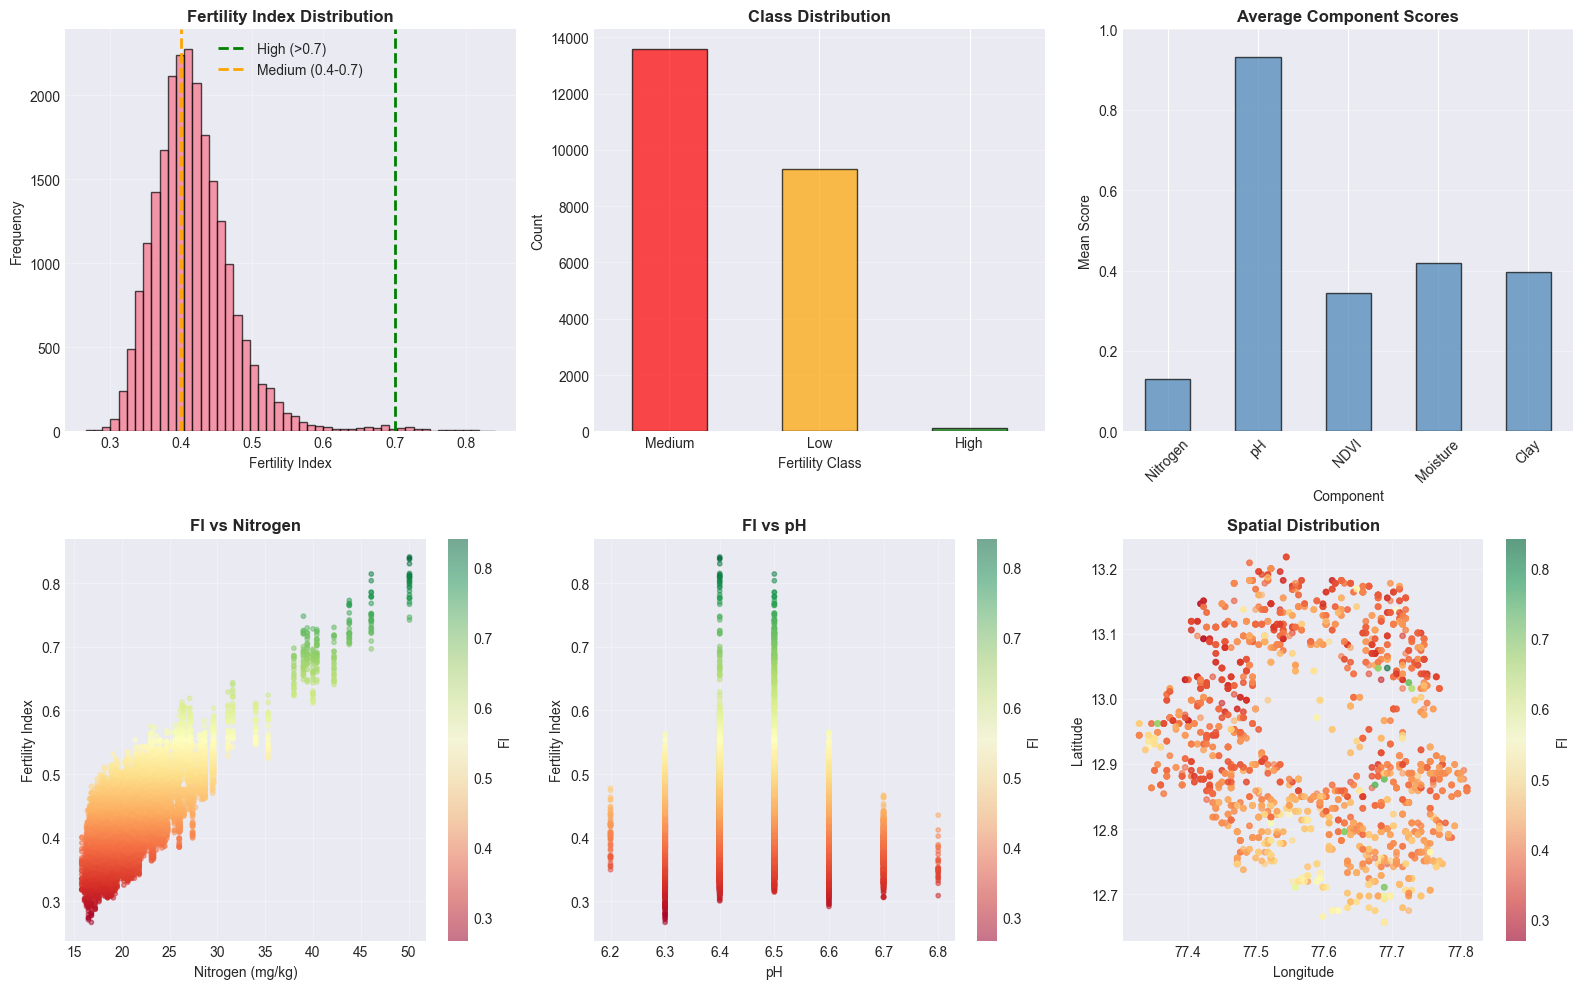

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("COMPOSITE FERTILITY INDEX - BASELINE MODEL")
print("="*80)

# STEP 1: LOAD DATA
print("\n1. LOADING DATA")
print("-" * 60)

df = pd.read_csv('csv/Bangalore_Monthly_Final_Corrected.csv')
print(f"Original shape: {df.shape}")

# Parse date and extract coordinates
df['date'] = pd.to_datetime(df['date'])

import json
def extract_coordinates(geo_str):
    try:
        geo_dict = json.loads(geo_str)
        coords = geo_dict['coordinates']
        return coords[0], coords[1]
    except:
        return None, None

df['longitude'], df['latitude'] = zip(*df['.geo'].apply(extract_coordinates))

# STEP 2: DEFINE RESEARCH-BASED WEIGHTS
print("\n2. BASELINE WEIGHTS (From SEM & Fuzzy-AHP Studies)")
print("-" * 60)

WEIGHTS = {
    'Nitrogen': 0.40,
    'pH': 0.25,
    'NDVI': 0.15,
    'SoilMoisture': 0.10,
    'Clay': 0.10
}

print("\nComponent Weights:")
for component, weight in WEIGHTS.items():
    print(f"  {component:15s}: {weight:.2f}")
print(f"\nTotal weight: {sum(WEIGHTS.values()):.2f} ✓")

# STEP 3: NORMALIZATION FUNCTIONS
def normalize_minmax(values):
    scaler = MinMaxScaler()
    return scaler.fit_transform(values.values.reshape(-1, 1)).flatten()

def normalize_ph_optimal(ph_values, optimal=6.5, tolerance=1.0):
    deviation = np.abs(ph_values - optimal)
    scores = 1 - (deviation / tolerance)
    return np.clip(scores, 0, 1)

# STEP 4: CREATE NORMALIZED COMPONENTS (Min-Max Method)
print("\n3. CREATING FERTILITY INDEX (Min-Max Method)")
print("-" * 60)

df_fertility = df.copy()

df_fertility['N_score'] = normalize_minmax(df['Nitrogen'])
df_fertility['pH_score'] = normalize_ph_optimal(df['pH'])
df_fertility['NDVI_score'] = normalize_minmax(df['NDVI'])
df_fertility['Moisture_score'] = normalize_minmax(df['SoilMoisture'])
df_fertility['Clay_score'] = normalize_minmax(df['Clay'])

# Calculate Composite Fertility Index
df_fertility['FertilityIndex'] = (
    WEIGHTS['Nitrogen'] * df_fertility['N_score'] +
    WEIGHTS['pH'] * df_fertility['pH_score'] +
    WEIGHTS['NDVI'] * df_fertility['NDVI_score'] +
    WEIGHTS['SoilMoisture'] * df_fertility['Moisture_score'] +
    WEIGHTS['Clay'] * df_fertility['Clay_score']
)

print(f"✓ Fertility Index created")
print(f"  Range: [{df_fertility['FertilityIndex'].min():.3f}, {df_fertility['FertilityIndex'].max():.3f}]")
print(f"  Mean: {df_fertility['FertilityIndex'].mean():.3f} ± {df_fertility['FertilityIndex'].std():.3f}")

# STEP 5: FERTILITY CLASSES
def classify_fertility(fi_score):
    if fi_score >= 0.7:
        return 'High'
    elif fi_score >= 0.4:
        return 'Medium'
    else:
        return 'Low'

df_fertility['FertilityClass'] = df_fertility['FertilityIndex'].apply(classify_fertility)

print("\n4. FERTILITY CLASS DISTRIBUTION")
print("-" * 60)
print(df_fertility['FertilityClass'].value_counts(normalize=True).mul(100).round(2))

# STEP 6: VALIDATION
print("\n5. VALIDATION - Component Correlations")
print("-" * 60)

components = ['Nitrogen', 'pH', 'NDVI', 'SoilMoisture', 'Clay']
validation = pd.DataFrame({
    'Component': components,
    'Weight': [WEIGHTS[c] for c in components],
    'Correlation': [stats.pearsonr(df_fertility[c], df_fertility['FertilityIndex'])[0] for c in components]
})
print(validation.to_string(index=False))

# STEP 7: VISUALIZATION
print("\n6. CREATING VISUALIZATIONS")
print("-" * 60)

fig = plt.figure(figsize=(16, 10))

# Distribution
ax1 = plt.subplot(2, 3, 1)
plt.hist(df_fertility['FertilityIndex'], bins=50, alpha=0.7, edgecolor='black')
plt.axvline(0.7, color='green', linestyle='--', linewidth=2, label='High (>0.7)')
plt.axvline(0.4, color='orange', linestyle='--', linewidth=2, label='Medium (0.4-0.7)')
plt.xlabel('Fertility Index')
plt.ylabel('Frequency')
plt.title('Fertility Index Distribution', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Class distribution
ax2 = plt.subplot(2, 3, 2)
df_fertility['FertilityClass'].value_counts().plot(kind='bar', color=['red', 'orange', 'green'], alpha=0.7, edgecolor='black')
plt.xlabel('Fertility Class')
plt.ylabel('Count')
plt.title('Class Distribution', fontweight='bold')
plt.xticks(rotation=0)
plt.grid(alpha=0.3, axis='y')

# Component scores
ax3 = plt.subplot(2, 3, 3)
score_cols = ['N_score', 'pH_score', 'NDVI_score', 'Moisture_score', 'Clay_score']
df_fertility[score_cols].mean().plot(kind='bar', color='steelblue', alpha=0.7, edgecolor='black')
plt.xlabel('Component')
plt.ylabel('Mean Score')
plt.title('Average Component Scores', fontweight='bold')
plt.xticks(range(5), ['Nitrogen', 'pH', 'NDVI', 'Moisture', 'Clay'], rotation=45)
plt.ylim(0, 1)
plt.grid(alpha=0.3, axis='y')

# FI vs Nitrogen
ax4 = plt.subplot(2, 3, 4)
scatter = plt.scatter(df_fertility['Nitrogen'], df_fertility['FertilityIndex'], 
                     c=df_fertility['FertilityIndex'], cmap='RdYlGn', alpha=0.5, s=10)
plt.xlabel('Nitrogen (mg/kg)')
plt.ylabel('Fertility Index')
plt.title('FI vs Nitrogen', fontweight='bold')
plt.colorbar(scatter, label='FI')
plt.grid(alpha=0.3)

# FI vs pH
ax5 = plt.subplot(2, 3, 5)
scatter = plt.scatter(df_fertility['pH'], df_fertility['FertilityIndex'], 
                     c=df_fertility['FertilityIndex'], cmap='RdYlGn', alpha=0.5, s=10)
plt.xlabel('pH')
plt.ylabel('Fertility Index')
plt.title('FI vs pH', fontweight='bold')
plt.colorbar(scatter, label='FI')
plt.grid(alpha=0.3)

# Spatial distribution
ax6 = plt.subplot(2, 3, 6)
sample_idx = np.random.choice(len(df_fertility), min(3000, len(df_fertility)), replace=False)
scatter = plt.scatter(df_fertility.iloc[sample_idx]['longitude'], 
                     df_fertility.iloc[sample_idx]['latitude'],
                     c=df_fertility.iloc[sample_idx]['FertilityIndex'], 
                     cmap='RdYlGn', alpha=0.6, s=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Spatial Distribution', fontweight='bold')
plt.colorbar(scatter, label='FI')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fertility_index_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: fertility_index_analysis.png")

# STEP 8: CREATE TRAIN/VAL/TEST SPLITS
print("\n7. CREATING TRAIN/VAL/TEST SPLITS")
print("-" * 60)

df_fertility['Year'] = df_fertility['date'].dt.year
df_fertility['Month_Actual'] = df_fertility['date'].dt.month
df_fertility_sorted = df_fertility.sort_values(['date', 'longitude', 'latitude']).reset_index(drop=True)

train_mask = ((df_fertility_sorted['Year'] == 2021) | 
              ((df_fertility_sorted['Year'] == 2022) & (df_fertility_sorted['Month_Actual'] <= 6)))
val_mask = ((df_fertility_sorted['Year'] == 2022) & (df_fertility_sorted['Month_Actual'] >= 7))
test_mask = df_fertility_sorted['Year'] == 2023

# Extract targets
y_train = df_fertility_sorted.loc[train_mask, 'FertilityIndex'].values
y_val = df_fertility_sorted.loc[val_mask, 'FertilityIndex'].values
y_test = df_fertility_sorted.loc[test_mask, 'FertilityIndex'].values

# Save
pd.DataFrame({'FertilityIndex': y_train}).to_csv('y_train.csv', index=False)
pd.DataFrame({'FertilityIndex': y_val}).to_csv('y_val.csv', index=False)
pd.DataFrame({'FertilityIndex': y_test}).to_csv('y_test.csv', index=False)

# Also save classes
y_train_class = df_fertility_sorted.loc[train_mask, 'FertilityClass'].values
y_val_class = df_fertility_sorted.loc[val_mask, 'FertilityClass'].values
y_test_class = df_fertility_sorted.loc[test_mask, 'FertilityClass'].values

pd.DataFrame({'FertilityClass': y_train_class}).to_csv('y_train_class.csv', index=False)
pd.DataFrame({'FertilityClass': y_val_class}).to_csv('y_val_class.csv', index=False)
pd.DataFrame({'FertilityClass': y_test_class}).to_csv('y_test_class.csv', index=False)

print(f"✓ Saved target CSVs:")
print(f"  - y_train.csv: {len(y_train)} samples")
print(f"  - y_val.csv: {len(y_val)} samples")
print(f"  - y_test.csv: {len(y_test)} samples")
print(f"  - y_*_class.csv: Classification targets")

# Save full data
output_cols = ['date', 'longitude', 'latitude', 'Nitrogen', 'pH', 'NDVI', 'SoilMoisture', 'Clay',
               'FertilityIndex', 'FertilityClass']
df_fertility[output_cols].to_csv('fertility_index_data.csv', index=False)
print(f"\n✓ Saved: fertility_index_data.csv")

print("\n" + "="*80)
print("✅ COMPOSITE FERTILITY INDEX CREATED SUCCESSFULLY!")
print("="*80)

print(f"\n📊 SUMMARY:")
print(f"  Mean FI: {df_fertility['FertilityIndex'].mean():.3f}")
print(f"  Std FI: {df_fertility['FertilityIndex'].std():.3f}")
print(f"\n  High: {(df_fertility['FertilityClass']=='High').sum()/len(df_fertility)*100:.1f}%")
print(f"  Medium: {(df_fertility['FertilityClass']=='Medium').sum()/len(df_fertility)*100:.1f}%")
print(f"  Low: {(df_fertility['FertilityClass']=='Low').sum()/len(df_fertility)*100:.1f}%")